In [45]:
# import library
import pandas as pd

In [ ]:
# initialize dataframes
icd_code_df = pd.read_csv("icd_code.csv", index_col=0)
df_final = pd.read_csv("final_data.csv", index_col=0)

In [47]:
# only need code and primary category for merging with diag columns
icd_lookup = icd_code_df[['code', 'primary_category']].drop_duplicates(subset='code')

# strip decimal from diag columns to standardize and match CSV format
for col in ['diag_1', 'diag_2', 'diag_3']:
    df_final[col] = df_final[col].astype(str).str.split('.').str[0].str.strip()

# standardize the code column too
icd_lookup['code'] = icd_lookup['code'].astype(str).str.strip()

# merge for each diag column
for col in ['diag_1', 'diag_2', 'diag_3']:
    df_final = df_final.merge(
        icd_lookup.rename(columns={'code': col, 'primary_category': f'{col}_category'}),
        on=col,
        how='left'
    )
    df_final[f'{col}_category'] = df_final[f'{col}_category'].fillna('Other')
    df_final = df_final.drop(columns=[col])

print(df_final['diag_1_category'].value_counts())

diag_1_category
Diseases Of The Circulatory System                                                                    25029
Endocrine, Nutritional And Metabolic Diseases, And Immunity Disorders                                  8965
Diseases Of The Respiratory System                                                                     8557
Diseases Of The Digestive System                                                                       7532
Symptoms, Signs, And Ill-Defined Conditions                                                            6187
Injury And Poisoning                                                                                   5780
Diseases Of The Genitourinary System                                                                   4294
Diseases Of The Musculoskeletal System And Connective Tissue                                           3915
Other                                                                                                  3253
Neoplasms   

In [48]:
# encode categorical variables for modeling
df_model = pd.get_dummies(df_final, columns=['race', 'gender', 'age', 'diag_1_category', 'diag_2_category', 'diag_3_category'], drop_first=True)
df_model.head(5)

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,...,diag_3_category_Diseases Of The Skin And Subcutaneous Tissue,"diag_3_category_Endocrine, Nutritional And Metabolic Diseases, And Immunity Disorders",diag_3_category_Infectious And Parasitic Diseases,diag_3_category_Injury And Poisoning,diag_3_category_Mental Disorders,diag_3_category_Neoplasms,diag_3_category_Other,diag_3_category_Supplementary Classification Of External Causes Of Injury And Poisoning,diag_3_category_Supplementary Classification Of Factors Influencing Health Status And Contact With Health Services,"diag_3_category_Symptoms, Signs, And Ill-Defined Conditions"
0,1,1,7,3,0,18,0,0,0,9,...,False,True,False,False,False,False,False,False,False,False
1,1,1,7,2,5,13,2,0,1,6,...,False,False,False,False,False,False,False,False,True,False
2,1,1,7,2,1,16,0,0,0,7,...,False,False,False,False,False,False,False,False,False,False
3,1,1,7,1,0,8,0,0,0,5,...,False,True,False,False,False,False,False,False,False,False
4,2,1,2,3,6,16,0,0,0,9,...,False,True,False,False,False,False,False,False,False,False


In [49]:
X = df_model.drop(columns=['readmitted'])
y = df_model['readmitted']

print(y.value_counts())

readmitted
0    73857
1     9397
Name: count, dtype: int64


In [50]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Training size: (66603, 79)
Test size: (16651, 79)


In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
print("Logistic Regression done")

Logistic Regression done


In [54]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest done")

Random Forest done


In [55]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
print("Gradient Boosting done")

Gradient Boosting done


In [56]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

gb_preds = gb.predict(X_test)
gb_probs = gb.predict_proba(X_test)[:, 1]

In [57]:
print("Logistic Regression")
print(classification_report(y_test, lr_preds))

print("Random Forest")
print(classification_report(y_test, rf_preds))

print("Gradient Boosting")
print(classification_report(y_test, gb_preds))

Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     14772
           1       0.45      0.04      0.07      1879

    accuracy                           0.89     16651
   macro avg       0.67      0.52      0.50     16651
weighted avg       0.84      0.89      0.84     16651

Random Forest
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     14772
           1       0.54      0.02      0.03      1879

    accuracy                           0.89     16651
   macro avg       0.72      0.51      0.49     16651
weighted avg       0.85      0.89      0.84     16651

Gradient Boosting
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     14772
           1       0.48      0.02      0.04      1879

    accuracy                           0.89     16651
   macro avg       0.69      0.51      0.49     16651
weighted avg       0.8

In [58]:
lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)
gb_auc = roc_auc_score(y_test, gb_probs)

print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"Random Forest AUC:       {rf_auc:.4f}")
print(f"Gradient Boosting AUC:   {gb_auc:.4f}")

Logistic Regression AUC: 0.7022
Random Forest AUC:       0.7548
Gradient Boosting AUC:   0.7760


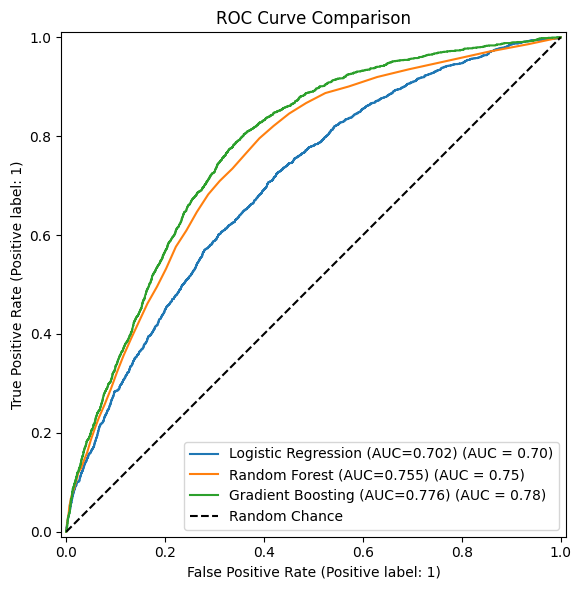

In [59]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, lr_probs, name=f"Logistic Regression (AUC={lr_auc:.3f})", ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_probs, name=f"Random Forest (AUC={rf_auc:.3f})", ax=ax)
RocCurveDisplay.from_predictions(y_test, gb_probs, name=f"Gradient Boosting (AUC={gb_auc:.3f})", ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Random Chance')
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.tight_layout()
plt.show()

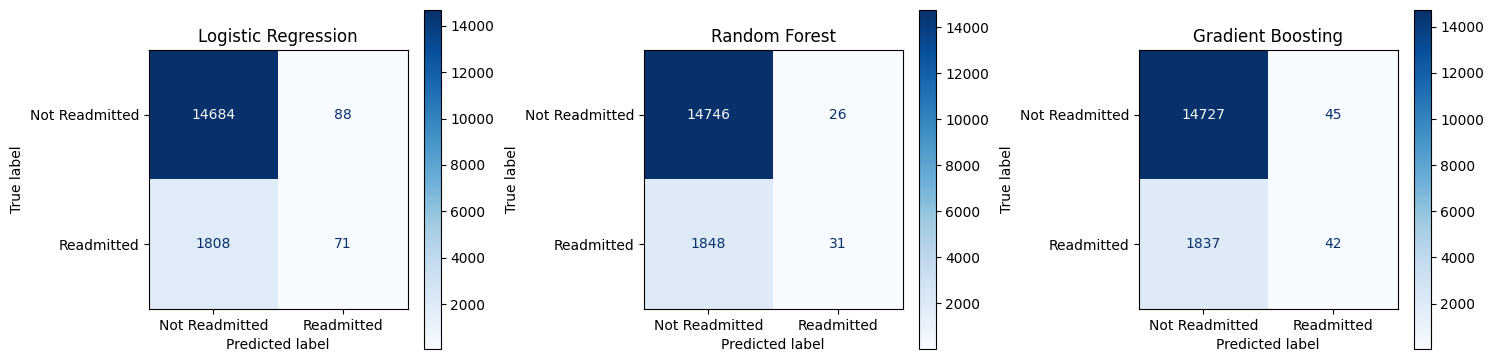

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Logistic Regression
cm = confusion_matrix(y_test, lr_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title('Logistic Regression')

# Random Forest
cm = confusion_matrix(y_test, rf_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title('Random Forest')

# Gradient Boosting
cm = confusion_matrix(y_test, gb_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap=plt.cm.Blues, ax=axes[2])
axes[2].set_title('Gradient Boosting')

plt.tight_layout()
plt.show()

Version 2: Fix the class imbalance between not readmitted and readmitted

In [61]:
from sklearn.utils.class_weight import compute_sample_weight

lr_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_balanced.fit(X_train_scaled, y_train)

rf_balanced = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_balanced.fit(X_train, y_train)

gb_balanced = GradientBoostingClassifier(n_estimators=100, random_state=42)


sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
gb_balanced.fit(X_train, y_train, sample_weight=sample_weights)

print("Balanced models trained!")



Balanced models trained!


In [62]:
lr_balanced_preds = lr_balanced.predict(X_test_scaled)
lr_balanced_probs = lr_balanced.predict_proba(X_test_scaled)[:, 1]

rf_balanced_preds = rf_balanced.predict(X_test)
rf_balanced_probs = rf_balanced.predict_proba(X_test)[:, 1]

gb_balanced_preds = gb_balanced.predict(X_test)
gb_balanced_probs = gb_balanced.predict_proba(X_test)[:, 1]

print("Balanced Logistic Regression")
print(classification_report(y_test, lr_balanced_preds))

print("Balanced Random Forest")
print(classification_report(y_test, rf_balanced_preds))

print("Balanced Gradient Boosting")
print(classification_report(y_test, gb_balanced_preds))

lr_balanced_auc = roc_auc_score(y_test, lr_balanced_probs)
rf_balanced_auc = roc_auc_score(y_test, rf_balanced_probs)
gb_balanced_auc = roc_auc_score(y_test, gb_balanced_probs)

print(f"Balanced Logistic Regression AUC: {lr_balanced_auc:.4f}")
print(f"Balanced Random Forest AUC:       {rf_balanced_auc:.4f}")
print(f"Balanced Gradient Boosting AUC:   {gb_balanced_auc:.4f}")

Balanced Logistic Regression
              precision    recall  f1-score   support

           0       0.93      0.75      0.83     14772
           1       0.22      0.54      0.31      1879

    accuracy                           0.73     16651
   macro avg       0.57      0.65      0.57     16651
weighted avg       0.85      0.73      0.77     16651

Balanced Random Forest
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     14772
           1       0.55      0.01      0.02      1879

    accuracy                           0.89     16651
   macro avg       0.72      0.51      0.48     16651
weighted avg       0.85      0.89      0.84     16651

Balanced Gradient Boosting
              precision    recall  f1-score   support

           0       0.96      0.66      0.78     14772
           1       0.23      0.78      0.35      1879

    accuracy                           0.67     16651
   macro avg       0.59      0.72      0.57     1

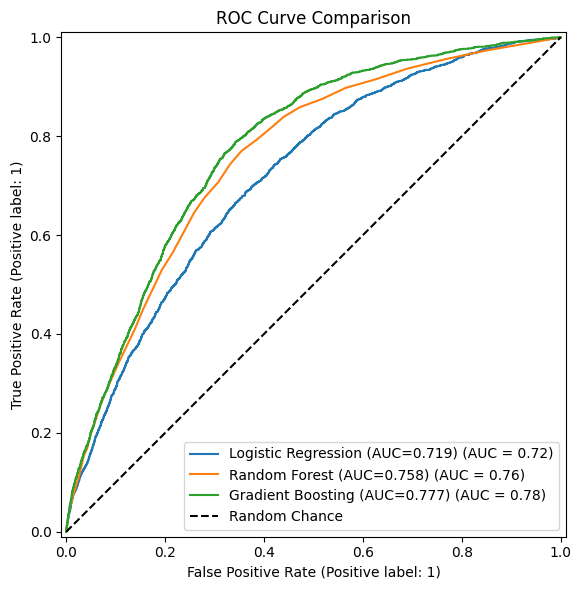

In [63]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, lr_balanced_probs, name=f"Logistic Regression (AUC={lr_balanced_auc:.3f})", ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_balanced_probs, name=f"Random Forest (AUC={rf_balanced_auc:.3f})", ax=ax)
RocCurveDisplay.from_predictions(y_test, gb_balanced_probs, name=f"Gradient Boosting (AUC={gb_balanced_auc:.3f})", ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Random Chance')
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.tight_layout()
plt.show()

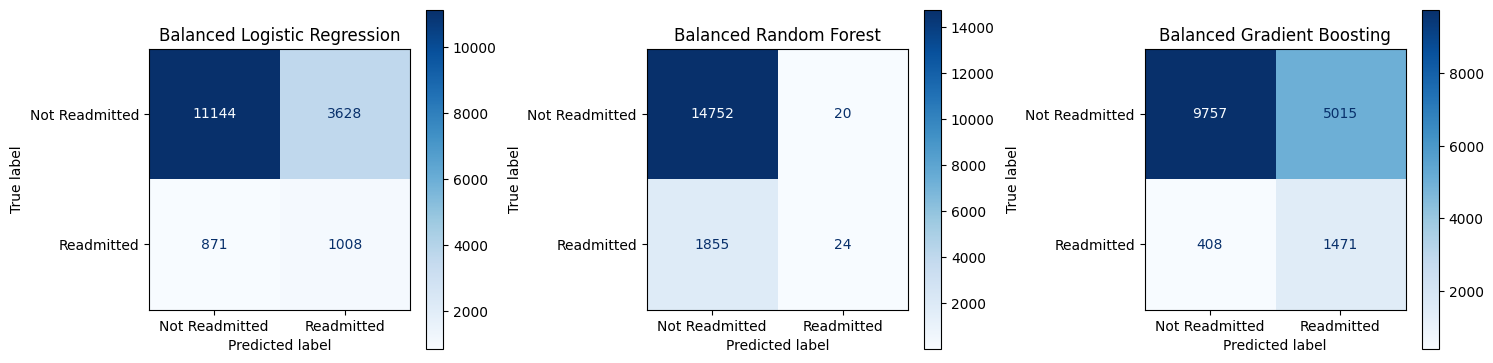

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Balanced Logistic Regression
cm = confusion_matrix(y_test, lr_balanced_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title('Balanced Logistic Regression')

# Balanced Random Forest
cm = confusion_matrix(y_test, rf_balanced_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title('Balanced Random Forest')

# Balanced Gradient Boosting
cm = confusion_matrix(y_test, gb_balanced_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap=plt.cm.Blues, ax=axes[2])
axes[2].set_title('Balanced Gradient Boosting')

plt.tight_layout()
plt.show()

Hyperparameter tuning of the gradient boosting model

In [65]:

from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.8, 1.0]
}

In [66]:
gb_tuned = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

gb_tuned.fit(X_train, y_train, sample_weight=sample_weights_train)

print("Best parameters:", gb_tuned.best_params_)
print("Best AUC score:", gb_tuned.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'subsample': 0.8, 'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 4, 'learning_rate': 0.05}
Best AUC score: 0.7857341015951744


In [67]:
gb_best = gb_tuned.best_estimator_

gb_tuned_preds = gb_best.predict(X_test)
gb_tuned_probs = gb_best.predict_proba(X_test)[:, 1]

print("Tuned Gradient Boosting")
print(classification_report(y_test, gb_tuned_preds))
print(f"Tuned Gradient Boosting AUC: {roc_auc_score(y_test, gb_tuned_probs):.4f}")

Tuned Gradient Boosting
              precision    recall  f1-score   support

           0       0.96      0.66      0.78     14772
           1       0.23      0.78      0.35      1879

    accuracy                           0.67     16651
   macro avg       0.59      0.72      0.57     16651
weighted avg       0.88      0.67      0.73     16651

Tuned Gradient Boosting AUC: 0.7803


Explainable AI (SHAP)

In [68]:
import sys
!{sys.executable} -m pip install shap


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
import shap

explainer = shap.TreeExplainer(gb_best)
shap_values = explainer.shap_values(X_test)

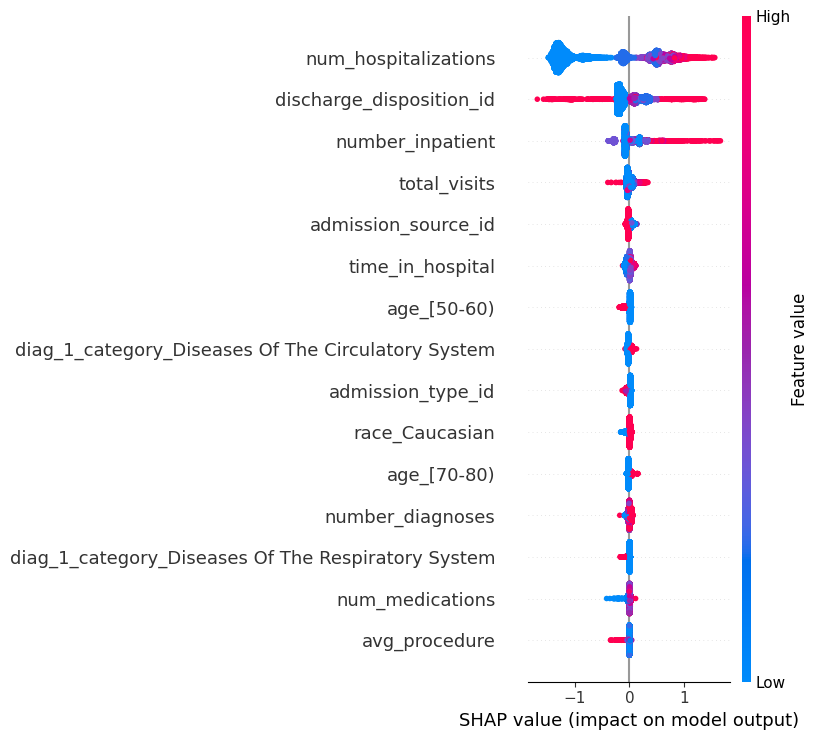

In [70]:
# Summary dot plot
shap.summary_plot(shap_values, X_test, max_display=15)

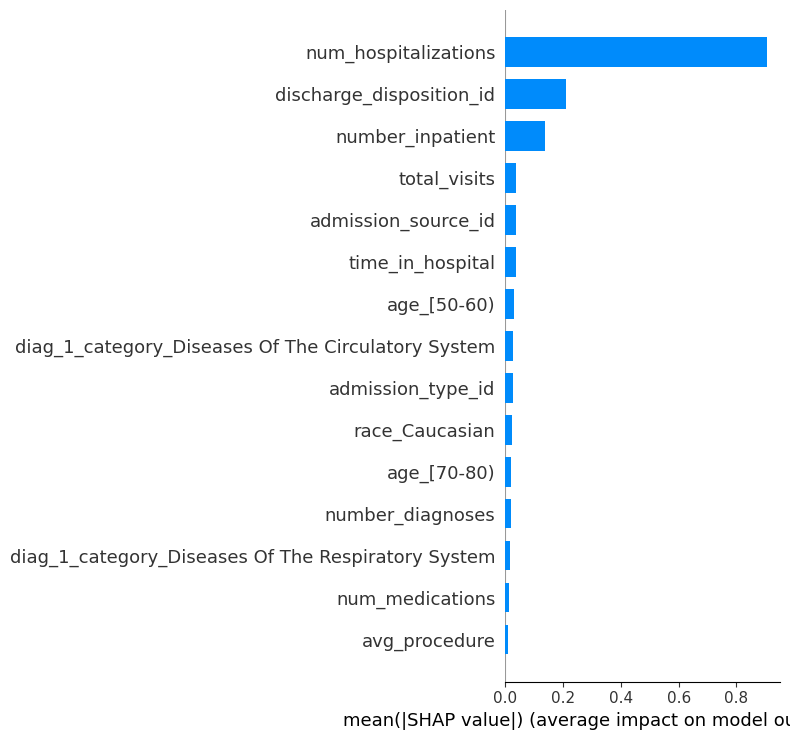

In [71]:
# Summary bar chart
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15)

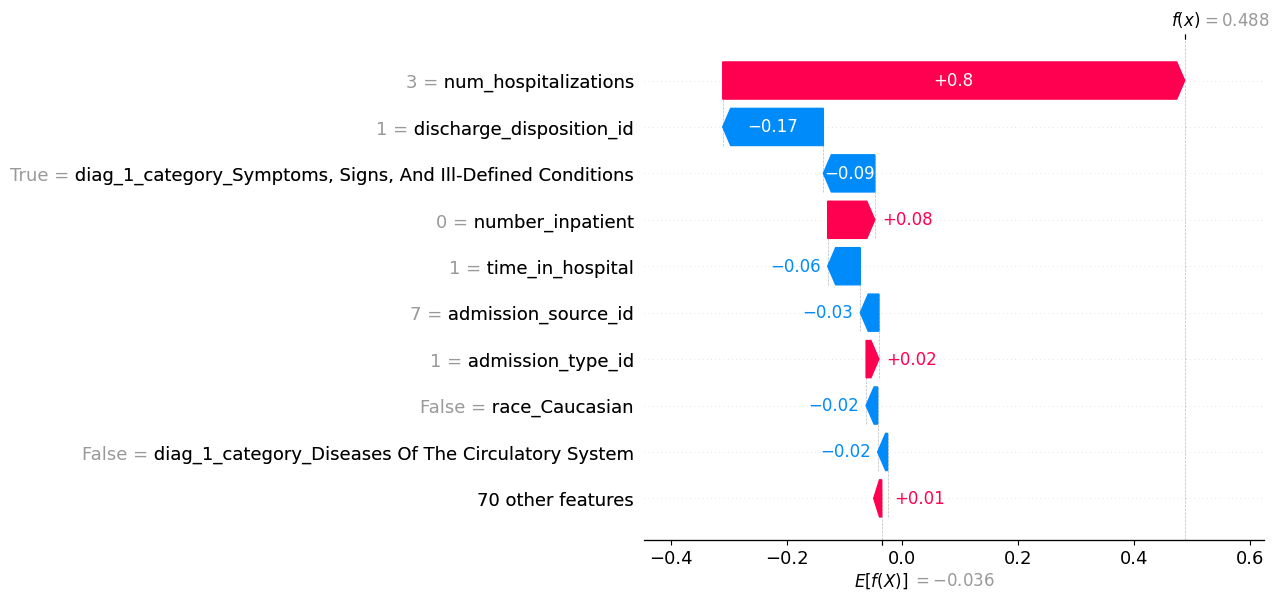

In [72]:
# Waterfall plot - explains the reasoning for the first patient in the test set
shap.plots.waterfall(explainer(X_test)[0])

In [ ]:
import pickle

with open('gb_model.pkl', 'wb') as f:
    pickle.dump(gb_best, f)

with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X_test.columns), f)

print("Saved")